# The Mass Index reversal bulge — a quantitative teardown 🔬
### Bulge event study (forward return vs base rate, raw & trend-signed) · one-sample & Welch *t* + a rare-event placebo · a net-Sharpe fade race with a HAC *t* on the daily difference · cost/variant sweeps · a 5-ETF panel · a synthetic planted-reversal control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Calls_reversals%3F: Busted](https://img.shields.io/badge/Calls_reversals%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Dorsey's Mass Index is sold as a **reversal** detector built from the **range**. We test that literally: treat each bulge as an event, measure the forward return against the base rate (raw *and* signed against the trend), then turn it into a timing rule and race it **net of costs, excess-of-cash** against buy-and-hold.

> ⚠️ **Data note.** SPY daily OHLCV (yfinance, auto-adjusted = **total-return** proxy), 2005-01-03→2026-06-23, **21 years**, as-of **2026-06-23** (the partial 2026-06-24 bar is dropped). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mass_index import data, strategy as st

ASOF = "2026-06-23"
HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    SPY = data.load_real("SPY")
    SPY = SPY[SPY.index <= ASOF]      # drop the partial current bar (house rule)
else:
    SPY = None
print("real SPY cache present:", HAVE_REAL,
      "| days:", (0 if SPY is None else len(SPY)),
      "| last:", (None if SPY is None else SPY.index[-1].date()))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-23', 'start': '2005-01-03', 'end': '2026-06-23', 'years': 21.4, 'n_days': 5401, 'fp': 'aec1923d846c', 'n_bulge': 36, 'raw': [(5, 0.0015, 0.0024, 0.64, 0.32, -0.2, 0.757), (10, -0.0049, 0.0047, 0.58, -0.7, -1.38, 0.531), (20, 0.0007, 0.0094, 0.67, 0.06, -0.76, 0.968), (40, 0.0251, 0.0186, 0.69, 2.3, 0.59, 0.269)], 'fade': [(5, 0.0084, -0.0005, 0.53, 1.95, 2.06, 0.039), (10, 0.0085, -0.001, 0.47, 1.25, 1.39, 0.116), (20, 0.0159, -0.001, 0.56, 1.42, 1.5, 0.039), (40, 0.0034, -0.0018, 0.53, 0.29, 0.44, 0.761)], 'fade_sharpe': 0.754, 'hold_sharpe': 0.637, 'fade_cagr': 0.122, 'hold_cagr': 0.108, 'fade_mdd': -0.485, 'hold_mdd': -0.552, 'fade_tim': 0.9, 'fade_turn': 2.5, 't_vs_hold': 0.67, 'variants': [('hold10 L/F', 0.711, 1.01), ('hold10 L/S', 0.745, 1.0), ('hold20 L/F', 0.754, 0.67), ('hold20 L/S', 0.735, 0.66), ('hold40 L/F', 0.657, -0.82), ('hold40 L/S', 0.461, -0.84)], 'costs': [(0.0, 0.755, 0.69), (1.0, 0.754, 0.67), (2.0, 0.753, 0.66), (5.0, 0.748, 0.6)], 'panel': [('SPY', 36, 0.0159, 1.42, 0.754, 0.637, 0.67), ('QQQ', 29, -0.0062, -0.48, 0.834, 0.768, 0.27), ('IWM', 19, 0.0073, 0.34, 0.536, 0.473, 0.88), ('DIA', 31, 0.0063, 0.57, 0.738, 0.619, 0.56), ('GLD', 23, -0.0124, -0.97, 0.6, 0.648, -1.34)], 'syn': [(0.0, 57, -0.0045, -0.5, 0.93, 0.257, 0.364, -0.85), (3.0, 79, 0.1668, 3.94, 0.0, 2.787, 0.258, 4.74)]}


real SPY cache present: True | days: 5401 | last: 2026-06-23


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Forward return after 36 bulges matches the base rate (20-day bulge **+0.07%** vs base **+0.94%**, *t* vs base **-0.76**); the directional fade peaks at one-sample *t* = **1.95** — below the *t ≥ 2* bar — and flips sign across the panel. |
| **Tradability** | `MIRAGE` | Post-bulge fade net Sharpe **0.75** vs buy-and-hold **0.64**, but HAC *t* of the daily difference = **0.67** (insignificant); long 90% of the time, ~2.5 round-trips/yr — it *is* buy-and-hold. |
| **Calls reversals?** | `BUSTED` | A bulge is volatility clustering; the synthetic control with a *planted* reversal lights up (*t* = **3.94**), proving the harness would catch a real one — and the real tape shows none. |

> 💡 In plain words: a *reversal* signal must predict **direction**, not just turbulence. The bulge predicts turbulence (range widening) and nothing about which way price goes.

## 1 · The claim, steelmanned

Dorsey's Mass Index is a rolling sum of a single/double EMA ratio of the daily range:

$$\mathrm{MI}_t = \sum_{i=0}^{24} \frac{\mathrm{EMA}_9(H-L)_{t-i}}{\mathrm{EMA}_9\!\big(\mathrm{EMA}_9(H-L)\big)_{t-i}}.$$

The **reversal bulge** completes on the first bar where $\mathrm{MI}$, having risen above **27**, falls back below **26.5**. Let $B$ be the set of those bars and $r_{t\to t+H}$ the forward $H$-day return entered one day later. The believer's hypotheses:

- **H1 (something happens).** $\mathbb{E}[r_{t\to t+H}\mid t\in B]$ differs from the unconditional base rate.
- **H2 (it reverses).** Signed against the prevailing trend $T_t$, $\mathbb{E}[-T_t\, r_{t\to t+H}\mid t\in B] > 0$ with $t \ge 2$.
- **H3 (it's tradable).** A post-bulge fade rule beats buy-and-hold net of costs (HAC *t* of the daily difference $> 2$).

We find **H1 rejected** (after-bulge ≈ base rate, *t* vs base ≤ +0.59), **H2 rejected** (best one-sample *t* = 1.95, sign-unstable across the panel), **H3 rejected** (HAC *t* = 0.67).

## 2 · So what? — the base rate is the whole game

Two honesty rules govern this test. **(a) Always contrast with the base rate.** A one-sample *t* of after-bulge returns against **zero** can be "passed" by mere market drift — over 40 days SPY drifts up ~1.9% on *any* random window. The honest statistic is the **Welch *t* of bulge vs non-bulge** (does the bulge sample differ from everyday tape?). **(b) Treat it as the rare event it is.** Only ~36 bulges fired in 21 years, so we draw thousands of random equal-size trigger sets and ask how often chance reproduces the observed |mean| (the placebo). For the tradable race we book **excess-of-cash vs excess-of-cash**, apply **one execution lag once** (signal at close $t$, return over $t+1$), charge **one-way costs × NAV turnover**, and judge by the **HAC (Newey-West) *t*** of the daily difference.

## 3 · How we'd know — the protocol

- **Universe.** SPY daily OHLCV (yfinance, auto-adjusted), 2005-01-03→2026-06-23, **5,401** sessions / 21y; 5-ETF panel for robustness.
- **Indicator.** Mass Index (EMA 9, sum window 25); bulge = MI > 27 then < 26.5.
- **Event study.** Forward 5/10/20/40-day return after each bulge, raw and **signed against the 25-day-SMA trend**, vs the base rate.
- **Inference.** One-sample *t* vs 0; **Welch *t* vs the non-bulge base**; a 5,000-draw random-trigger placebo (rare-event null).
- **Timing.** Post-bulge fade, hold 20d; signal at close $t$, position over $t+1$; costs 1 bp one-way × NAV; borrow 50 bps/yr on shorts.
- **Race.** Net annualised Sharpe (excess-of-cash) vs buy-and-hold; **HAC *t*** of the daily difference; variant & cost sweeps.
- **Positive control.** A synthetic panel with a *planted* post-bulge reversal (knob `edge`): `edge=0` must NOT manufacture significance; a real `edge` must light up.

## 4 · The teardown

### 4a · The bulge event study — after-bulge return vs base rate

Raw forward return after each bulge (red) vs the non-bulge base rate (grey), with the Welch *t* of the difference. If the bulge carried information, the red bars separate.

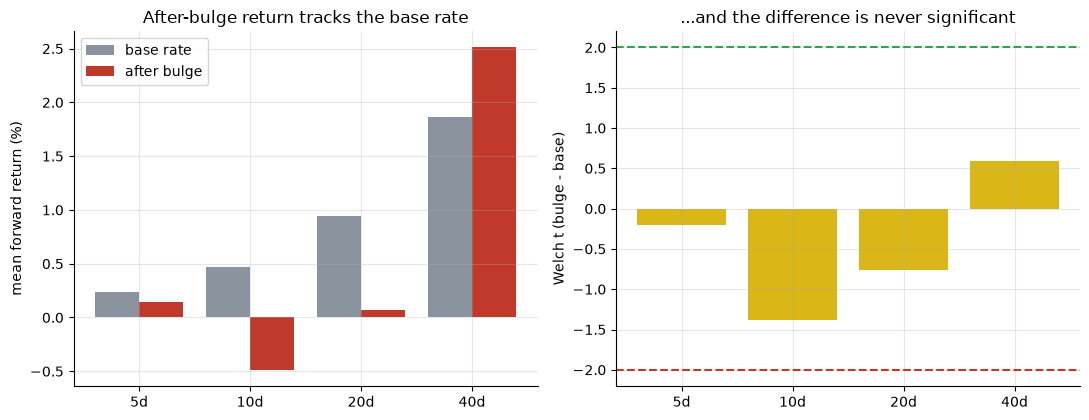

bulge%: [0.15, -0.49, 0.07, 2.51]
base%: [0.24, 0.47, 0.94, 1.86]
t_vs_base: [-0.2, -1.38, -0.76, 0.59]


In [2]:
H=[r[0] for r in R['raw']]
if HAVE_REAL:
    bm=[];bb=[];tvb=[]
    for h in H:
        e=st.event_study(SPY,h,fade=False); bm.append(e['bulge_mean']*100); bb.append(e['base_mean']*100); tvb.append(e['t_vs_base'])
else:
    bm=[r[1]*100 for r in R['raw']]; bb=[r[2]*100 for r in R['raw']]; tvb=[r[5] for r in R['raw']]
x=np.arange(len(H)); fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,4.3))
a1.bar(x-.2,bb,.4,color=GREY,label='base rate'); a1.bar(x+.2,bm,.4,color=RED,label='after bulge')
a1.set_xticks(x);a1.set_xticklabels([f'{h}d' for h in H]);a1.set_ylabel('mean forward return (%)')
a1.set_title('After-bulge return tracks the base rate'); a1.legend()
a2.bar([f'{h}d' for h in H], tvb, color=[GREEN if abs(v)>=2 else AMBER for v in tvb])
a2.axhline(2,c=GREEN,ls='--'); a2.axhline(-2,c=RED,ls='--'); a2.set_ylabel('Welch t (bulge - base)')
a2.set_title('...and the difference is never significant'); plt.tight_layout(); plt.show()
print('bulge%:',[round(v,2) for v in bm]); print('base%:',[round(v,2) for v in bb]); print('t_vs_base:',[round(v,2) for v in tvb])

> 💡 In plain words: the after-bulge return is **statistically indistinguishable** from a random day — the Welch *t* never leaves the ±2 band (it's *negative* at 5/10/20d). The one tall 40-day bar (+2.51%) is just market drift (base +1.86%, *t* vs base only +0.59).

### 4b · The directional test — does fading the trend pay?

Forward return **signed against the prevailing trend** after a bulge (a real reversal → positive), with the one-sample *t* and the rare-event placebo *p*.

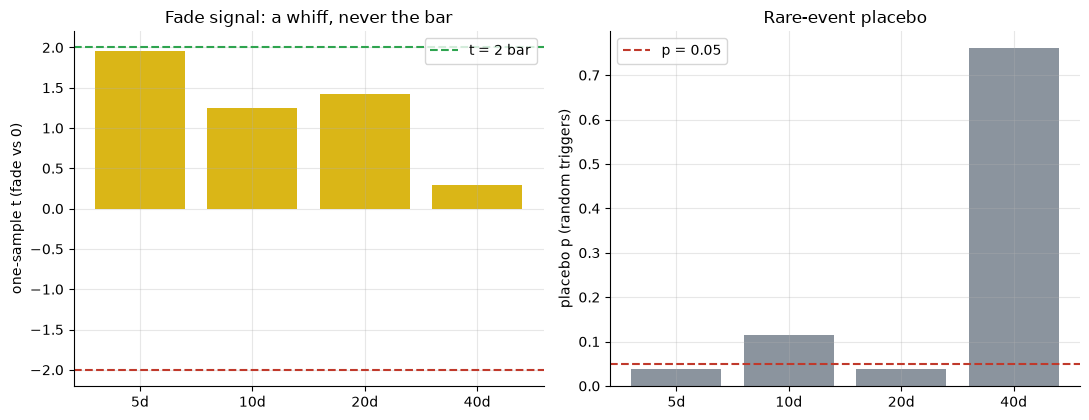

fade%: [0.84, 0.85, 1.59, 0.34]
t0: [1.95, 1.25, 1.42, 0.29]
placebo_p: [0.039, 0.116, 0.039, 0.761]


In [3]:
if HAVE_REAL:
    fm=[];tt=[];pp=[]
    for h in H:
        e=st.event_study(SPY,h,fade=True); pl=st.placebo_pvalue(SPY,h,fade=True,n_draws=5000)
        fm.append(e['bulge_mean']*100); tt.append(e['t_vs_zero']); pp.append(pl['p_value'])
else:
    fm=[r[1]*100 for r in R['fade']]; tt=[r[4] for r in R['fade']]; pp=[r[6] for r in R['fade']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,4.3))
a1.bar([f'{h}d' for h in H], tt, color=[GREEN if abs(v)>=2 else AMBER for v in tt])
a1.axhline(2,c=GREEN,ls='--',label='t = 2 bar'); a1.axhline(-2,c=RED,ls='--')
a1.set_ylabel('one-sample t (fade vs 0)'); a1.set_title('Fade signal: a whiff, never the bar'); a1.legend()
a2.bar([f'{h}d' for h in H], pp, color=GREY); a2.axhline(.05,c=RED,ls='--',label='p = 0.05')
a2.set_ylabel('placebo p (random triggers)'); a2.set_title('Rare-event placebo'); a2.legend()
plt.tight_layout(); plt.show()
print('fade%:',[round(v,2) for v in fm]); print('t0:',[round(v,2) for v in tt]); print('placebo_p:',[round(v,3) for v in pp])

> 💡 In plain words: the fade is positive everywhere, and 5d/20d brush *p* = 0.039 — but the one-sample *t* tops out at **1.95**, below the desk's *t ≥ 2* bar, and the pattern is non-monotone (gone by 40 days). On 36 events, this is the texture of *almost-nothing*, and the inference bar forbids calling it real. **WEAK at most → NONE.**

### 4c · The timing race — net Sharpe & the HAC *t*

Post-bulge fade (hold 20d, long/flat) vs buy-and-hold, growth of \$1 excess-of-cash, and the HAC *t* of the daily (fade − buy-hold) difference.

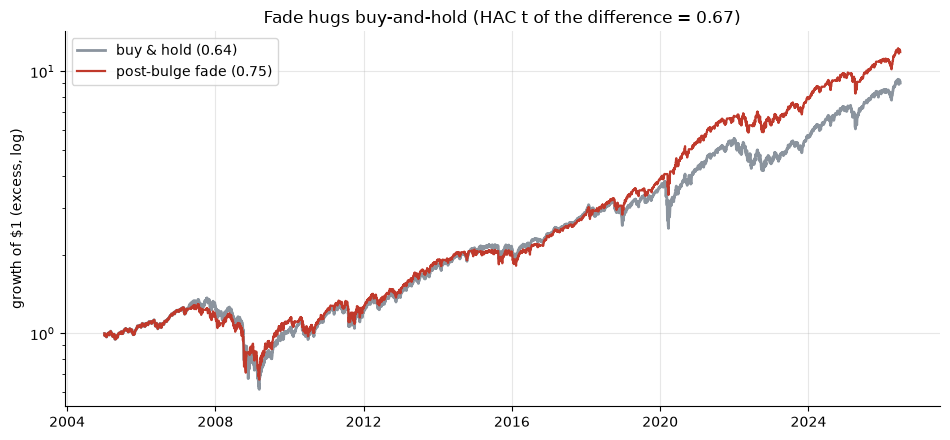

fade Sharpe 0.754  buy-hold 0.637  HAC t = 0.67


In [4]:
if HAVE_REAL:
    pos=st.fade_position(SPY,hold=20); bk=st.book_returns(SPY,pos,cost_bps=1.0)
    eq_hold=(1+bk['asset_excess']).cumprod(); eq_f=(1+bk['strat_excess']).cumprod(); idx=SPY.index
    fs=st.sharpe(bk['strat_excess'].values); hs=st.sharpe(bk['asset_excess'].values)
    tval=st.hac_t(bk['strat_excess'].values-bk['asset_excess'].values)
else:
    idx=pd.bdate_range('2005-01-03',periods=R['n_days'])
    eq_hold=pd.Series(np.linspace(1,np.exp(R['hold_cagr']*R['years']),R['n_days']),index=idx)
    eq_f=pd.Series(np.linspace(1,np.exp(R['fade_cagr']*R['years']),R['n_days']),index=idx)
    fs=R['fade_sharpe']; hs=R['hold_sharpe']; tval=R['t_vs_hold']
fig,ax=plt.subplots(figsize=(9.6,4.5))
ax.plot(idx,eq_hold,c=GREY,lw=2,label=f'buy & hold ({hs:.2f})')
ax.plot(idx,eq_f,c=RED,lw=1.6,label=f'post-bulge fade ({fs:.2f})')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (excess, log)')
ax.set_title(f'Fade hugs buy-and-hold (HAC t of the difference = {tval:.2f})'); ax.legend()
plt.tight_layout(); plt.show()
print(f'fade Sharpe {fs:.3f}  buy-hold {hs:.3f}  HAC t = {tval:.2f}')

> 💡 In plain words: the fade Sharpe (**0.75**) edges buy-and-hold (**0.64**), but HAC *t* = **0.67** — the gap is noise. At 90% time-in-market and ~2.5 round-trips/yr, the rule *is* buy-and-hold with an occasional defensive tilt.

### 4d · Variants, costs & the panel — nothing significant, the sign isn't stable

Left: hold-length / long-short variants (none clear the bar; 40-day *hurts*). Right: the panel — the fade flips sign on QQQ and GLD.

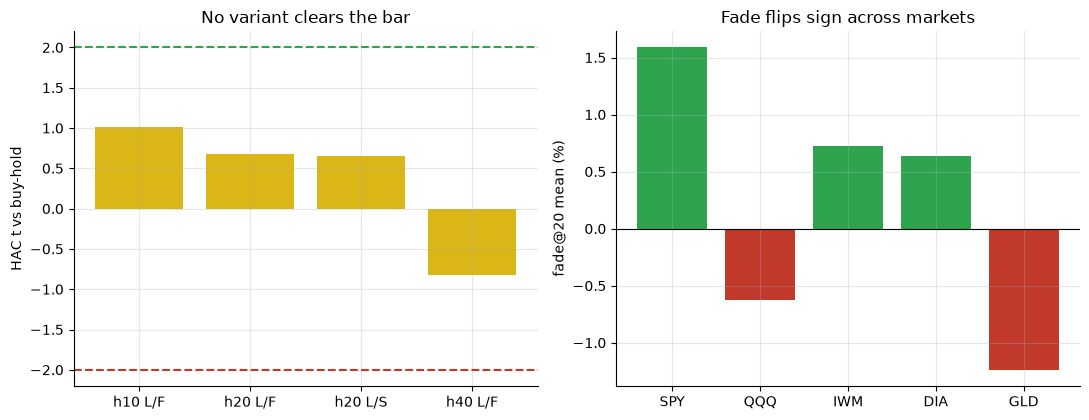

variant HAC t: [('h10 L/F', 1.01), ('h20 L/F', 0.67), ('h20 L/S', 0.66), ('h40 L/F', -0.82)]
panel fade@20%: [('SPY', 1.59), ('QQQ', -0.62), ('IWM', 0.73), ('DIA', 0.63), ('GLD', -1.24)]


In [5]:
if HAVE_REAL:
    var=[]
    for hold,ls,nm in [(10,False,'h10 L/F'),(20,False,'h20 L/F'),(20,True,'h20 L/S'),(40,False,'h40 L/F')]:
        rr=st.run_experiment(SPY,hold=hold,long_short=ls,cost_bps=1.0); var.append((nm,rr['t_vs_hold']))
    pan=[]
    for t,_,_,_,_,_,_ in R['panel']:
        if data.have_real(t):
            bb=data.load_real(t); bb=bb[bb.index<=ASOF]; e=st.event_study(bb,20,fade=True); pan.append((t,e['bulge_mean']*100))
        else:
            row=[p for p in R['panel'] if p[0]==t][0]; pan.append((t,row[2]*100))
else:
    var=[('h10 L/F',R['variants'][0][2]),('h20 L/F',R['variants'][2][2]),('h20 L/S',R['variants'][3][2]),('h40 L/F',R['variants'][4][2])]
    pan=[(p[0],p[2]*100) for p in R['panel']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,4.3))
a1.bar([v[0] for v in var],[v[1] for v in var],color=[GREEN if abs(v[1])>=2 else AMBER for v in var])
a1.axhline(2,c=GREEN,ls='--'); a1.axhline(-2,c=RED,ls='--'); a1.set_ylabel('HAC t vs buy-hold'); a1.set_title('No variant clears the bar')
a2.bar([p[0] for p in pan],[p[1] for p in pan],color=[GREEN if p[1]>0 else RED for p in pan])
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('fade@20 mean (%)'); a2.set_title('Fade flips sign across markets')
plt.tight_layout(); plt.show()
print('variant HAC t:',[(n,round(t,2)) for n,t in var]); print('panel fade@20%:',[(t,round(v,2)) for t,v in pan])

> 💡 In plain words: every timing variant's HAC *t* sits inside ±2 (the 40-day fade is *negative* — it sits out up-legs), and the event-study fade is **positive on SPY/IWM/DIA but negative on QQQ and GLD**. A real effect points the same way everywhere; a sign-flip across markets is the fingerprint of small-sample noise.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic synthetic panel with a **planted** post-bulge reversal (knob `edge`): `edge=0` must NOT manufacture significance; a real `edge` must light up. Both hold — so the dead real-tape result is a true negative, not a broken harness.

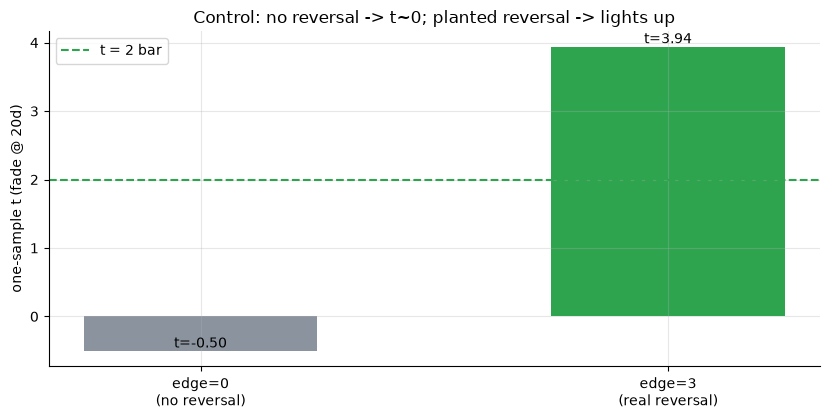

edge=0.0: fade@20=-0.45% t0=-0.50 placebo_p=0.930
edge=3.0: fade@20=+16.68% t0=+3.94 placebo_p=0.000


In [6]:
res=[]
for edge in (0.0, 3.0):
    bars,truth=data.synthetic_panel(n_days=6000,edge=edge,seed=429)
    e=st.event_study(bars,20,fade=True); pl=st.placebo_pvalue(bars,20,fade=True,n_draws=3000)
    res.append((edge,e['bulge_mean']*100,e['t_vs_zero'],pl['p_value']))
labels=[f'edge={e:.0f}\n(real reversal)' if e>0 else f'edge={e:.0f}\n(no reversal)' for e,_,_,_ in res]
tv=[r[2] for r in res]
fig,ax=plt.subplots(figsize=(8.4,4.3))
ax.bar(labels,tv,color=[GREY,GREEN],width=.5); ax.axhline(2,c=GREEN,ls='--',label='t = 2 bar')
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('one-sample t (fade @ 20d)'); ax.set_title('Control: no reversal -> t~0; planted reversal -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,m,t,p in res: print(f'edge={e:.1f}: fade@20={m:+.2f}% t0={t:+.2f} placebo_p={p:.3f}')

> 💡 In plain words: with **no** planted reversal the fade sits at *t* = **-0.50** (placebo *p* = 0.93 — no false positive); with a **real** planted reversal it explodes to *t* = **3.94** (placebo *p* = 0.000, timing Sharpe 2.79 vs 0.26). The engine *can* bank a post-bulge reversal when it exists — and on the real SPY tape, it doesn't exist.

## 5 · The verdict

- **Signal `NONE`** — after-bulge return matches the base rate at every horizon (20-day *t* vs base **-0.76**; the 40-day one-sample *t* = 2.30 is calendar drift); the directional fade peaks at *t* = **1.95** (sub-2) and flips sign on QQQ/GLD. Literature says reversal; this tape can't certify it.
- **Tradability `MIRAGE`** — post-bulge fade Sharpe **0.75** vs buy-and-hold **0.64**, HAC *t* = **0.67** (insignificant); long 90% of the time, ~2.5 round-trips/yr. It is buy-and-hold.
- **Calls reversals? `BUSTED`** — the bulge is volatility clustering; the synthetic control with a planted reversal lights up (*t* = **3.94**) while the real tape stays flat. Range tells you *a* move may come, never which way.

## 6 · Could you trade it? — no separable edge to deploy

The cost sweep makes the point: because the rule barely trades, costs are nearly irrelevant — which only underlines that there's no edge for costs to eat. Net Sharpe vs one-way cost, against the buy-and-hold line.

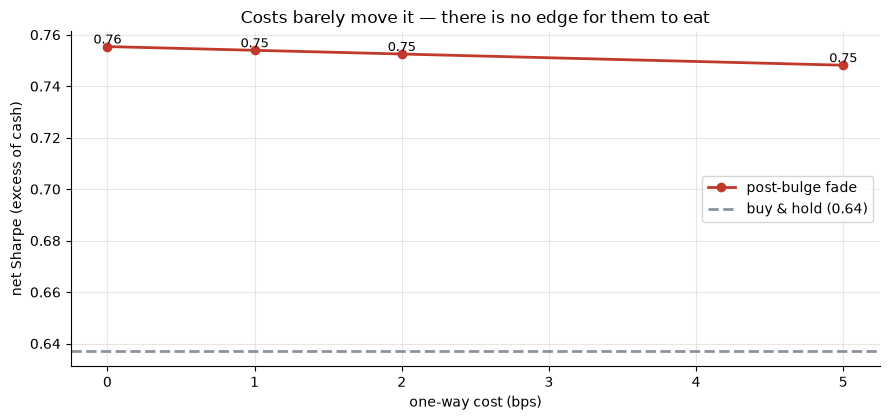

cost sweep: {0.0: 0.755, 1.0: 0.754, 2.0: 0.753, 5.0: 0.748}


In [7]:
cb=[c[0] for c in R['costs']]
if HAVE_REAL:
    shp=[st.run_experiment(SPY,hold=20,cost_bps=c)['fade_sharpe'] for c in cb]
else:
    shp=[c[1] for c in R['costs']]
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.plot(cb,shp,'o-',c=RED,lw=2,label='post-bulge fade')
ax.axhline(R['hold_sharpe'],c=GREY,ls='--',lw=2,label=f'buy & hold ({R["hold_sharpe"]:.2f})')
for x,y in zip(cb,shp): ax.annotate(f'{y:.2f}',(x,y),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe (excess of cash)')
ax.set_title('Costs barely move it — there is no edge for them to eat'); ax.legend()
plt.tight_layout(); plt.show()
print('cost sweep:',{c:round(s,3) for c,s in zip(cb,shp)})

> 💡 In plain words: from 0 to 5 bps the fade Sharpe moves from **0.76** to **0.75** — almost flat, because it trades so little. The thing that's missing isn't cheaper execution; it's a signal. **MIRAGE.**

## 7 · Going further

- **Threshold search is a trap.** Grid-searching the 27 / 26.5 levels (or the EMA/sum windows) until something beats buy-and-hold is curve-fitting (see the desk's data-mining demos). The *standard* recipe is the honest test, and it fails.
- **Volatility vs direction.** The Mass Index is a clean **volatility-clustering** detector — useful for sizing risk, not for calling turns. Pairing it with a genuine directional signal is a different study.
- **Why a range can't name the direction.** $H-L$ is symmetric in up- and down-moves; a function of the range carries magnitude, not sign. "The range tells you which way price reverses" is a category error — which is exactly what the flat tape, the sign-flipping panel, and the lit-up synthetic control jointly show.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*